## Import libraries and set path ##

In [5]:
# Standard libraries
import os
import pandas as pd
import seaborn as sns
import svgwrite
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap
from matplotlib.ticker import AutoMinorLocator

In [6]:
data_path = '/path/to/your/data/folder/Data for visulization/'
figure_path = '/path/to/your/data/folder/'

## Fig. 3|Growth of non-street-facing and non-ground-floor shops from 2015 to 2023

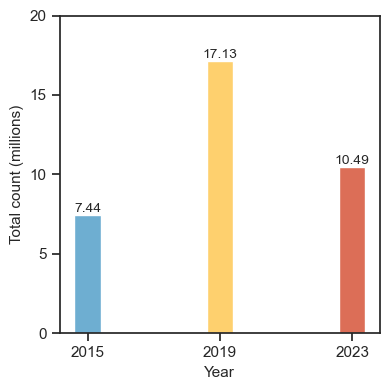

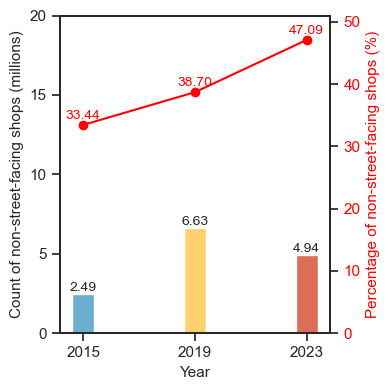

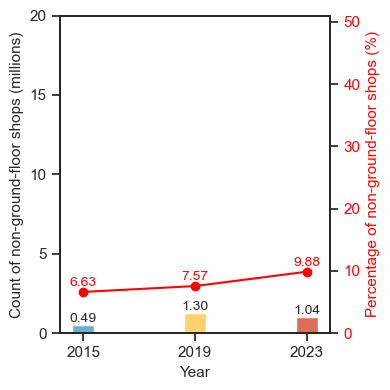

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



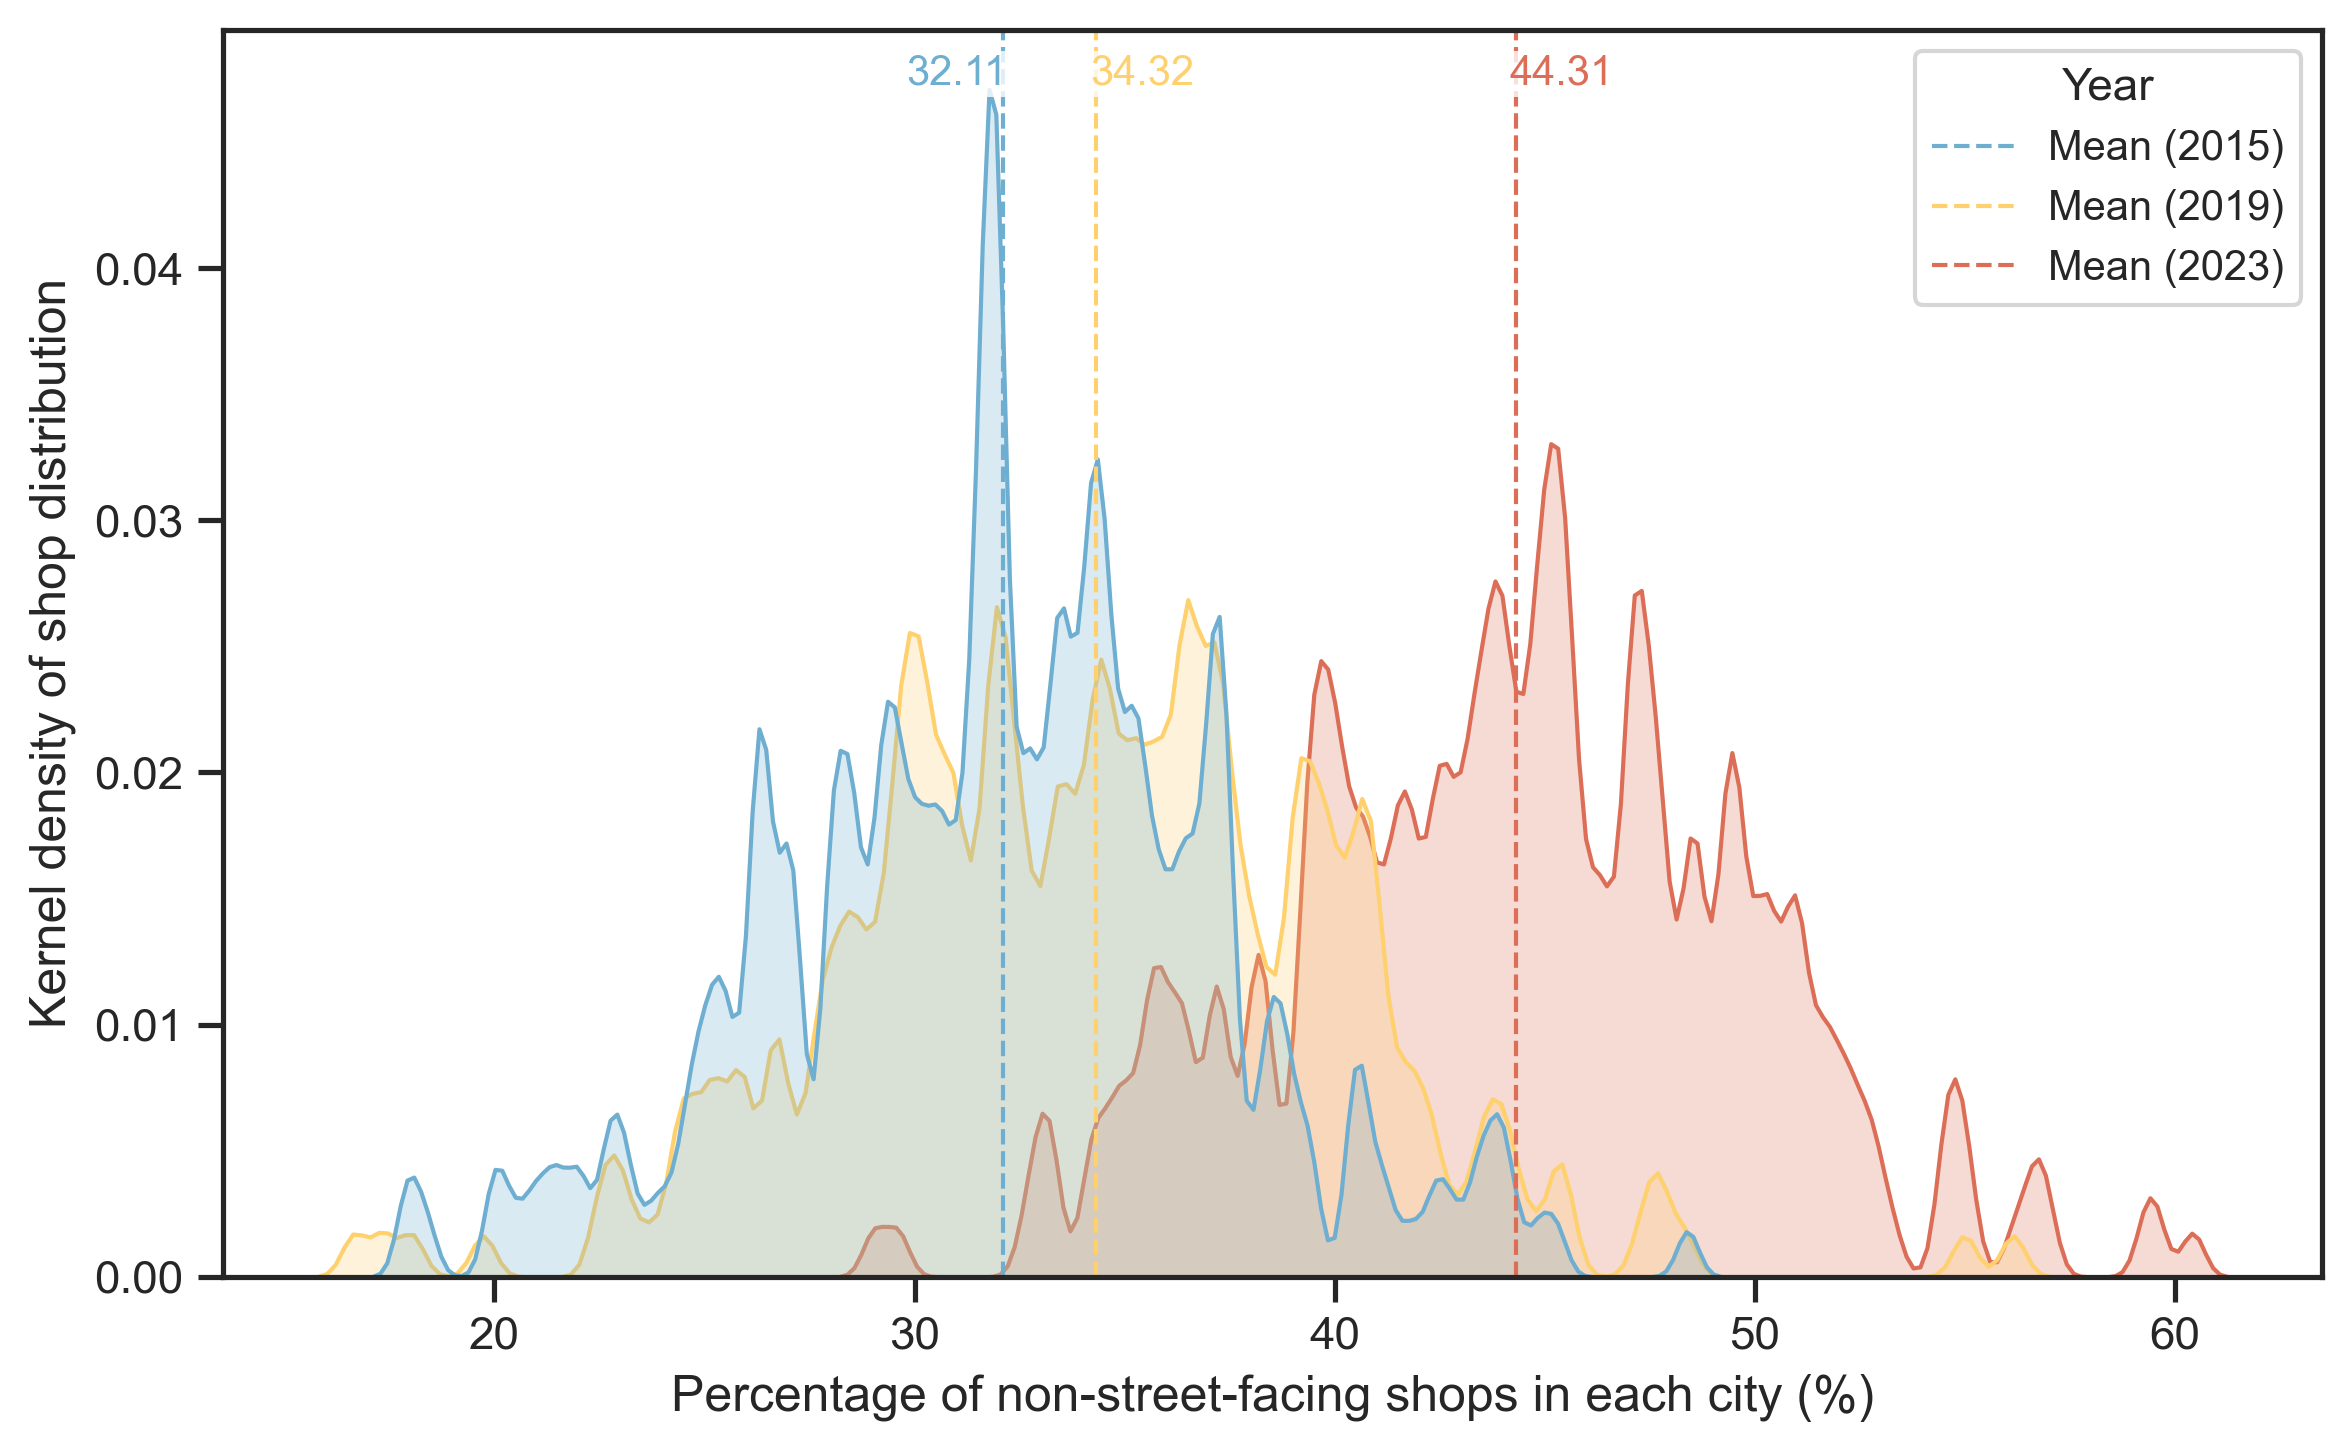

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



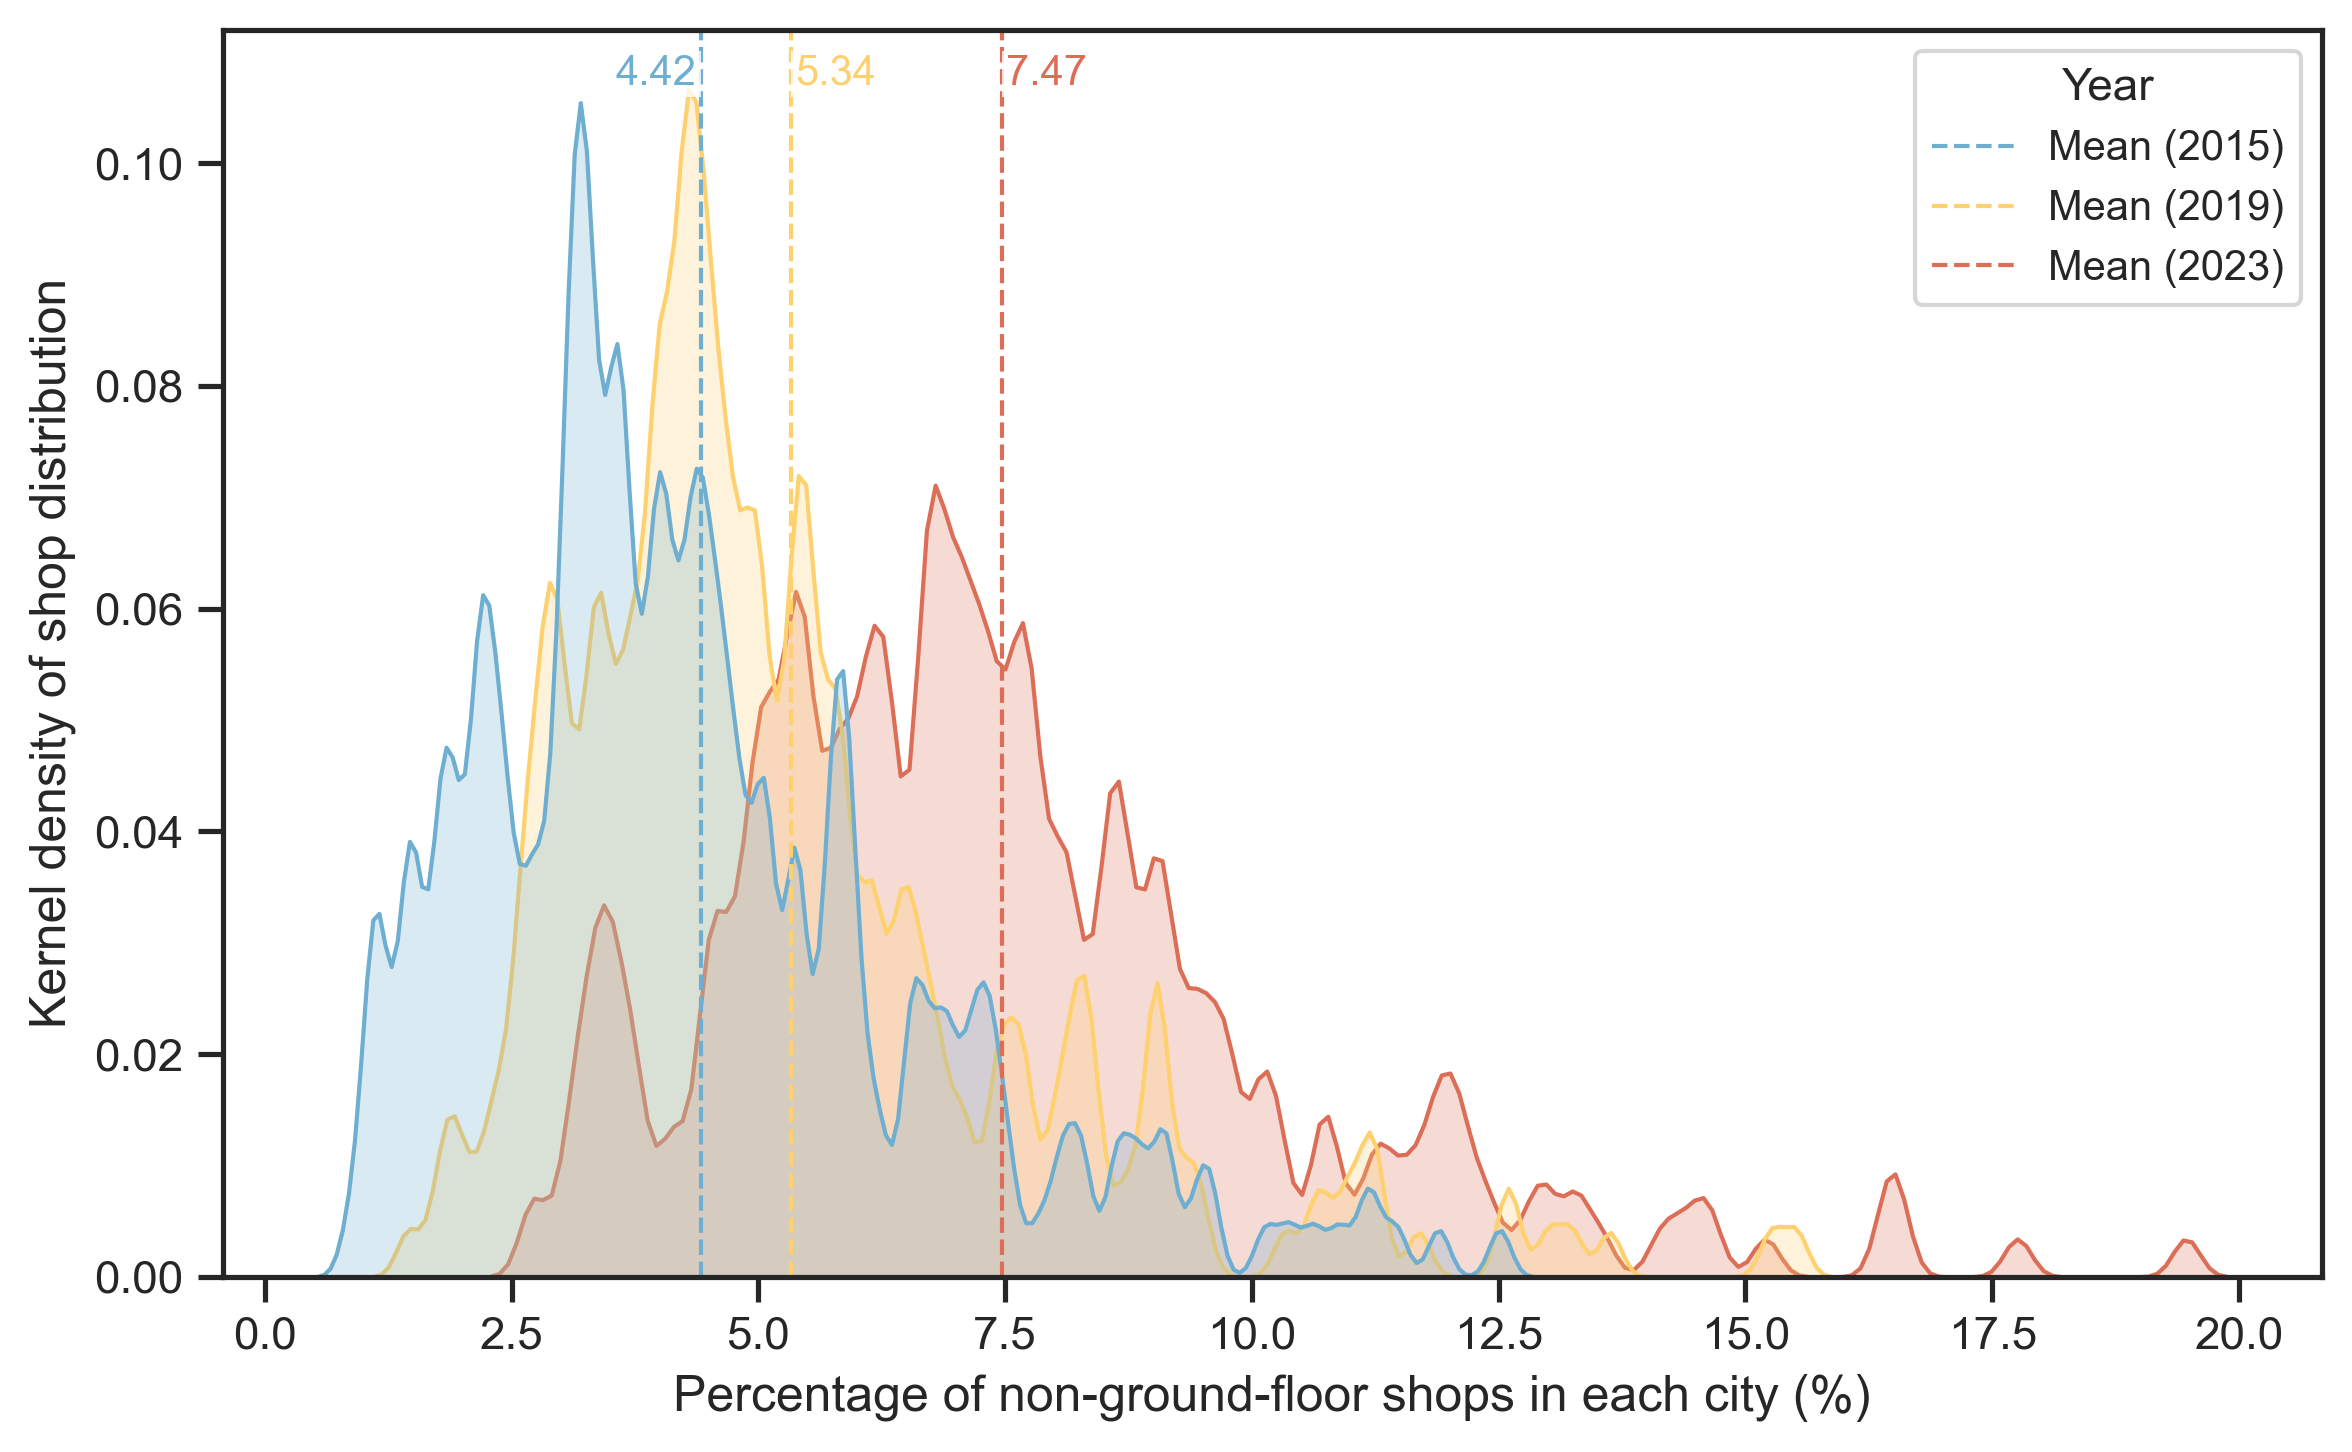

In [10]:
# Load and prepare data
dataS = pd.read_csv(data_path+'SummaryAll.csv')
dataC = pd.read_csv(data_path+'CityAll.csv')

# Save figure
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(f"{figure_path}/{filename}", format="svg", bbox_inches='tight')
    plt.show()

# Set global parameters
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12

def create_figure_template(figsize=(4, 4), dpi=100):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    return fig, ax

# Fig.3a. Total count
def create_fig3a(data):
    fig, ax = create_figure_template()
    colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
    bars = ax.bar(data['Year'], data['Count (millions)'], 
                color=[colors.get(year) for year in data['Year']], 
                width=0.8)
    
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
               f'{bar.get_height():.2f}', 
               ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Total count (millions)', fontsize=11)
    ax.set_xticks([2015, 2019, 2023])
    ax.set_ylim(0, 20)
    ax.set_yticks(range(0, 21, 5))
    
    save_figure("Fig_3a_count_by_year.svg")

# Fig.3b. NSF metrics
def create_fig3b(data):
    fig, ax1 = create_figure_template()
    colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
    bars = ax1.bar(data['Year'], data['NSF (millions)'],
                  color=[colors[year] for year in data['Year']],
                  width=0.8)
    
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=10)
    
    ax1.set_xlabel('Year', fontsize=11)
    ax1.set_ylabel('Count of non-street-facing shops (millions)', fontsize=11)
    ax1.set_xticks([2015, 2019, 2023])
    ax1.set_ylim(0, 20)
    ax1.set_yticks(range(0, 21, 5))
    ax2 = ax1.twinx()
    ax2.plot(data['Year'], data['P_NSF (%)'], color='red', marker='o', markersize=6, linewidth=1.5)
    ax2.set_ylabel('Percentage of non-street-facing shops (%)', fontsize=11, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 51)
    
    for x, y in zip(data['Year'], data['P_NSF (%)']):
        ax2.text(x, y + 0.5, f'{y:.2f}',
                ha='center', va='bottom', fontsize=10, color='red')
    
    save_figure("Fig_3b_NSF_dual_axis.svg")

# Fig.3c. NGF metrics
def create_fig3c(data):
    fig, ax1 = create_figure_template()
    colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
    bars = ax1.bar(data['Year'], data['NGF (millions)'],
                  color=[colors[year] for year in dataS['Year']],
                  width=0.8)
    
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=10)
    
    ax1.set_xlabel('Year', fontsize=11)
    ax1.set_ylabel('Count of non-ground-floor shops (millions)', fontsize=11)
    ax1.set_xticks([2015, 2019, 2023])
    ax1.set_ylim(0, 20)
    ax1.set_yticks(range(0, 21, 5))
    ax2 = ax1.twinx()
    ax2.plot(data['Year'], data['P_NGF (%)'], color='red', marker='o', markersize=6, linewidth=1.5)
    ax2.set_ylabel('Percentage of non-ground-floor shops (%)', fontsize=11, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 51)
    
    for x, y in zip(data['Year'], data['P_NGF (%)']):
        ax2.text(x, y + 0.5, f'{y:.2f}',
                ha='center', va='bottom', fontsize=10, color='red')
    
    save_figure("Fig_3c_NGF_dual_axis.svg")

# Fig.3d. NSF KDE 
def create_fig3d(data):
    sns.set_theme(style="white")
    sns.set_style('white', rc={'xtick.bottom': True, 'ytick.left': True})
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
    
    sns.kdeplot(data, x='P_Horizontal (%)', hue='Year',
               fill=True, bw_adjust=0.15, palette=colors,
               hue_order=[2015, 2019, 2023])
    
    ymin, ymax = ax.get_ylim()
    label_y = ymax * 0.98  
    legend_handles = []
    
    for year in [2015, 2019, 2023]:
        mean_val = data[data['Year'] == year]['P_Horizontal (%)'].mean()
        color = colors[year]  
        line = plt.axvline(mean_val, color=color, linestyle='dashed', linewidth=1, label=f'Mean ({year})')
        legend_handles.append(line)
        
        if year == 2015:
            label_x = mean_val - 1.1
        else:
            label_x = mean_val + 1.1
            
        plt.text(label_x, label_y, f'{mean_val:.2f}',
                color=color, ha='center', va='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    
    plt.xlabel('Percentage of non-street-facing shops in each city (%)', fontsize=12)
    plt.ylabel('Kernel density of shop distribution', fontsize=12)
    plt.legend(handles=legend_handles, fontsize=10, title='Year', title_fontsize=11)
    
    save_figure("Fig_3d_kde_NSF.svg")

# Fig.3e. NGF KDE 
def create_fig3e(data):
    sns.set_theme(style="white")
    sns.set_style('white', rc={'xtick.bottom': True, 'ytick.left': True})
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
    
    sns.kdeplot(data, x='P_Vertical (%)', hue='Year',
               fill=True, bw_adjust=0.15, palette=colors,
               hue_order=[2015, 2019, 2023])
    
    ymin, ymax = ax.get_ylim()
    label_y = ymax * 0.98  
    legend_handles = []
    
    for year in [2015, 2019, 2023]:
        mean_val = data[data['Year'] == year]['P_Vertical (%)'].mean()
        color = colors[year]  
        line = plt.axvline(mean_val, color=color, linestyle='dashed',linewidth=1, label=f'Mean ({year})')
        legend_handles.append(line)
        
        if year == 2015:
            label_x = mean_val - 0.45
        else:
            label_x = mean_val + 0.45
            
        plt.text(label_x, label_y, f'{mean_val:.2f}',
                color=color, ha='center', va='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
    
    plt.xlabel('Percentage of non-ground-floor shops in each city (%)', fontsize=12)
    plt.ylabel('Kernel density of shop distribution', fontsize=12)    
    plt.legend(handles=legend_handles, fontsize=10, title='Year', title_fontsize=11)
    
    save_figure("Fig_3e_kde_NGF.svg")

if __name__ == "__main__":
    create_fig3a(dataS)   # Fig.3a - Total count
    create_fig3b(dataS)   # Fig 3b - NSF metrics
    create_fig3c(dataS)   # Fig 3c - NGF metrics
    create_fig3d(dataC)   # Fig.3d - NSF KDE
    create_fig3e(dataC)   # Fig.3e - NGF KDE

## Fig. 4|Expansion trends across different establishment categories ##

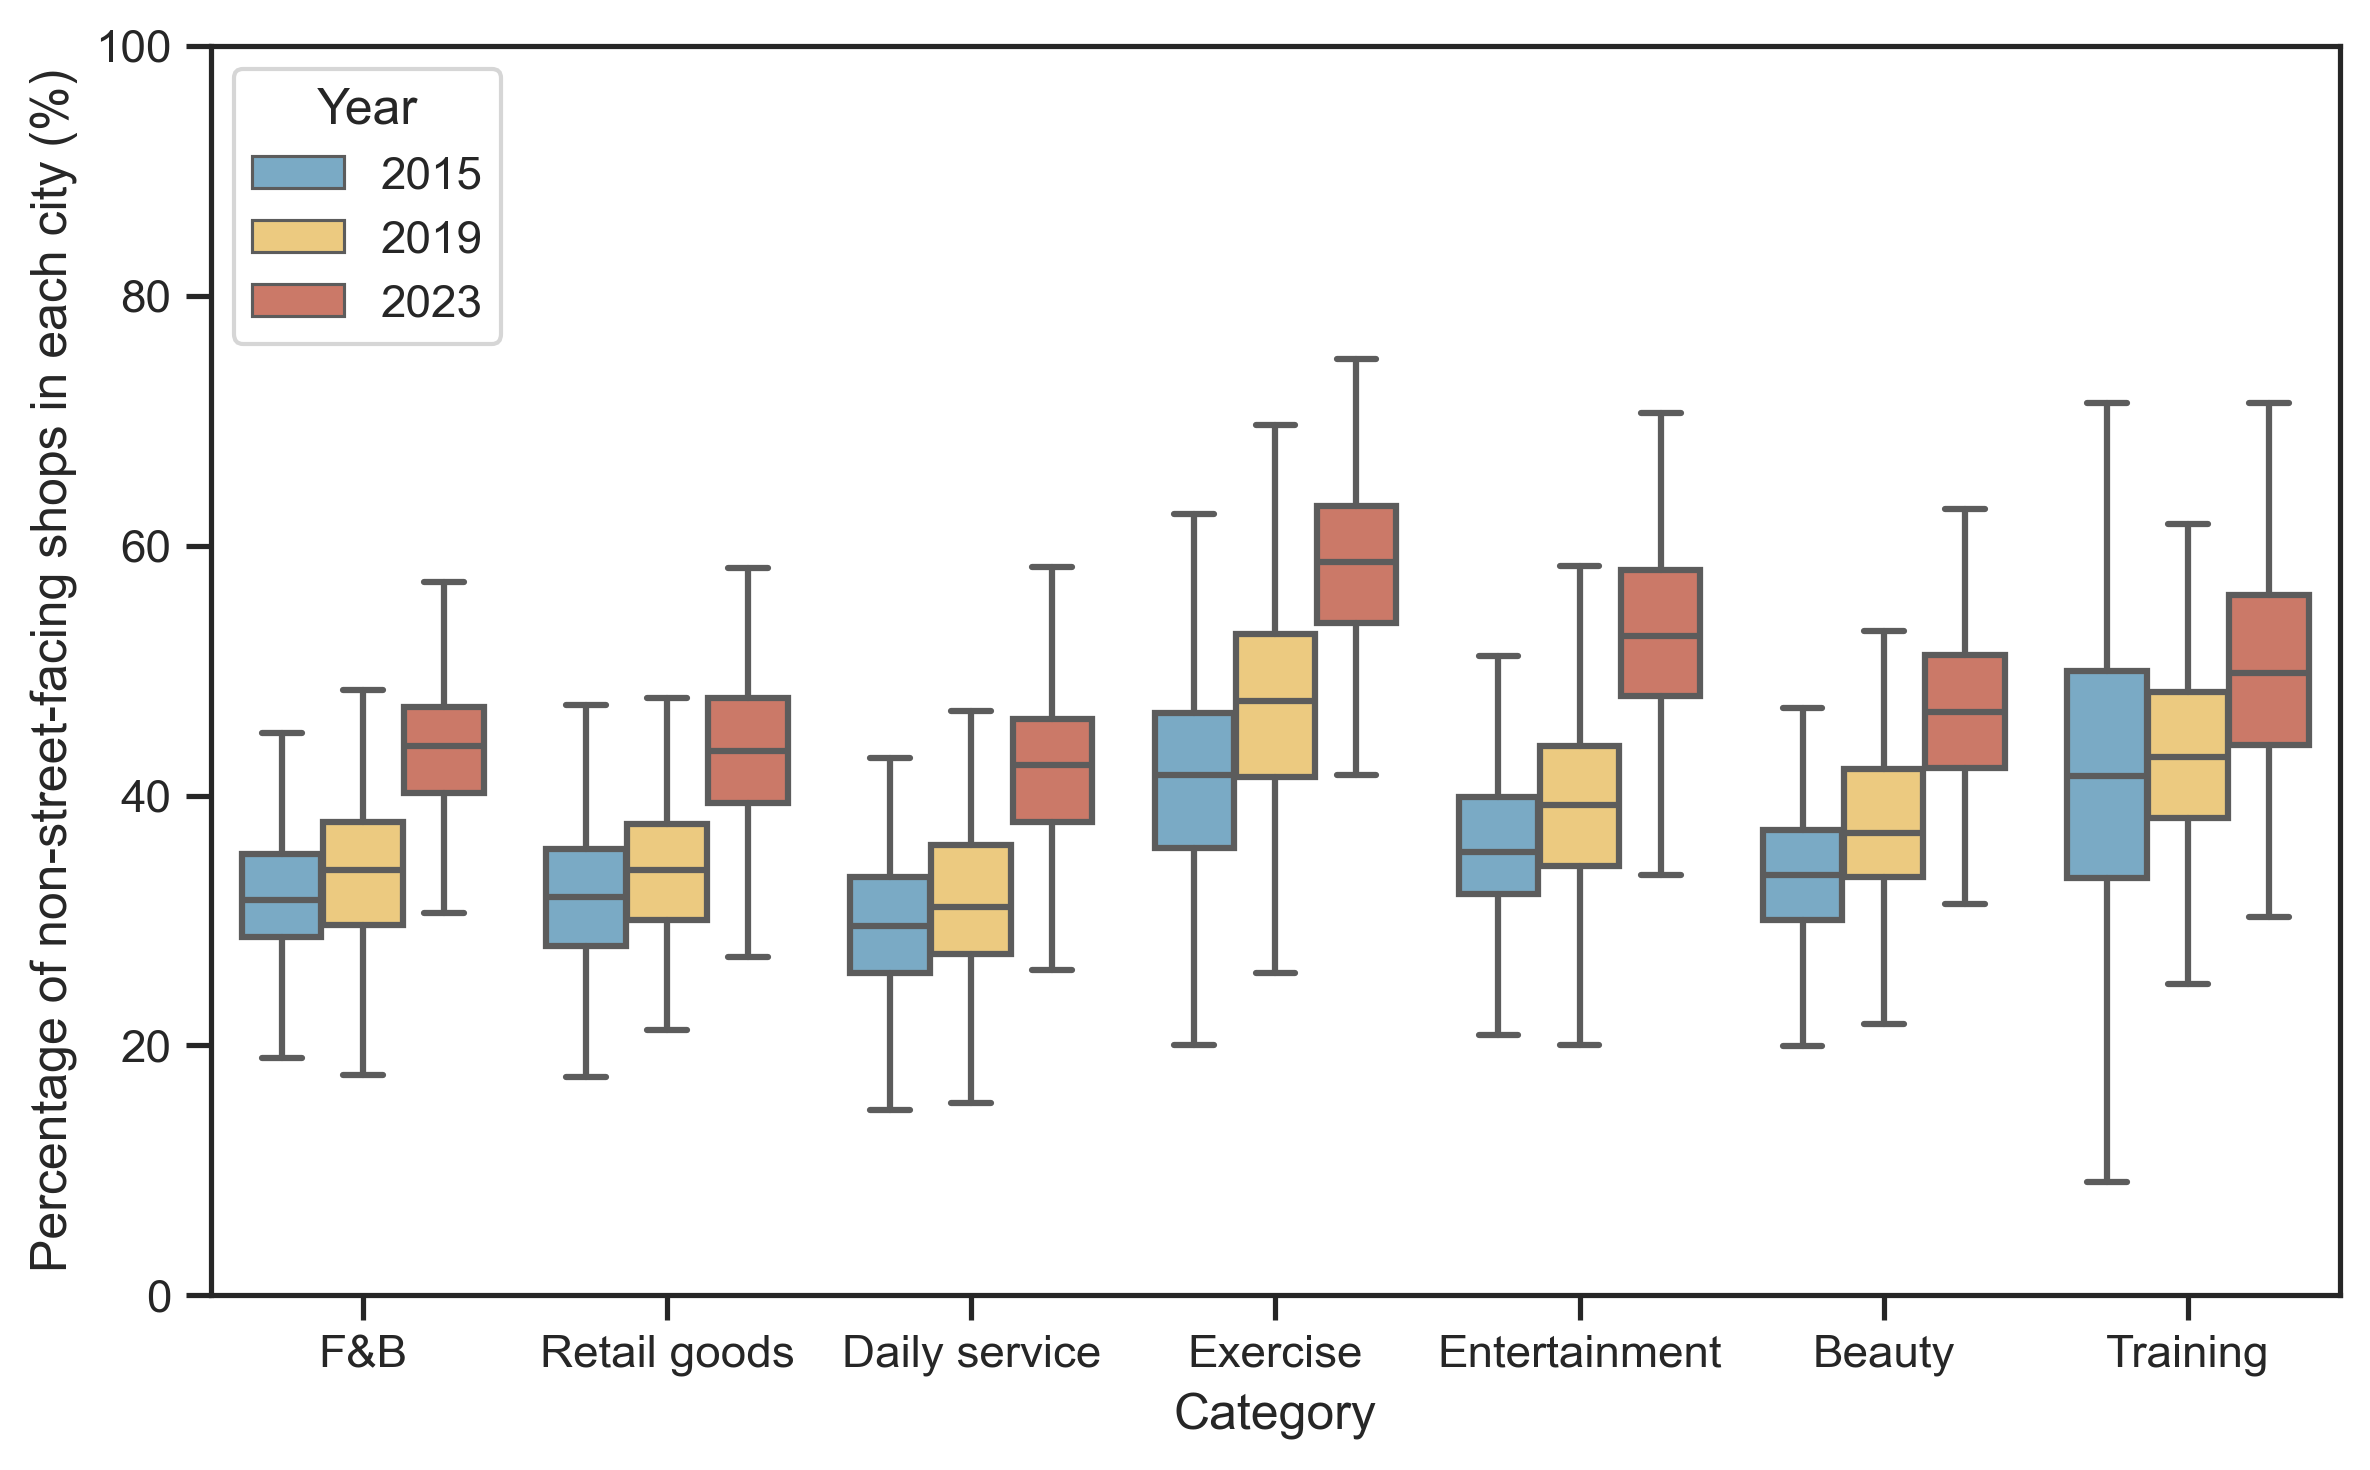

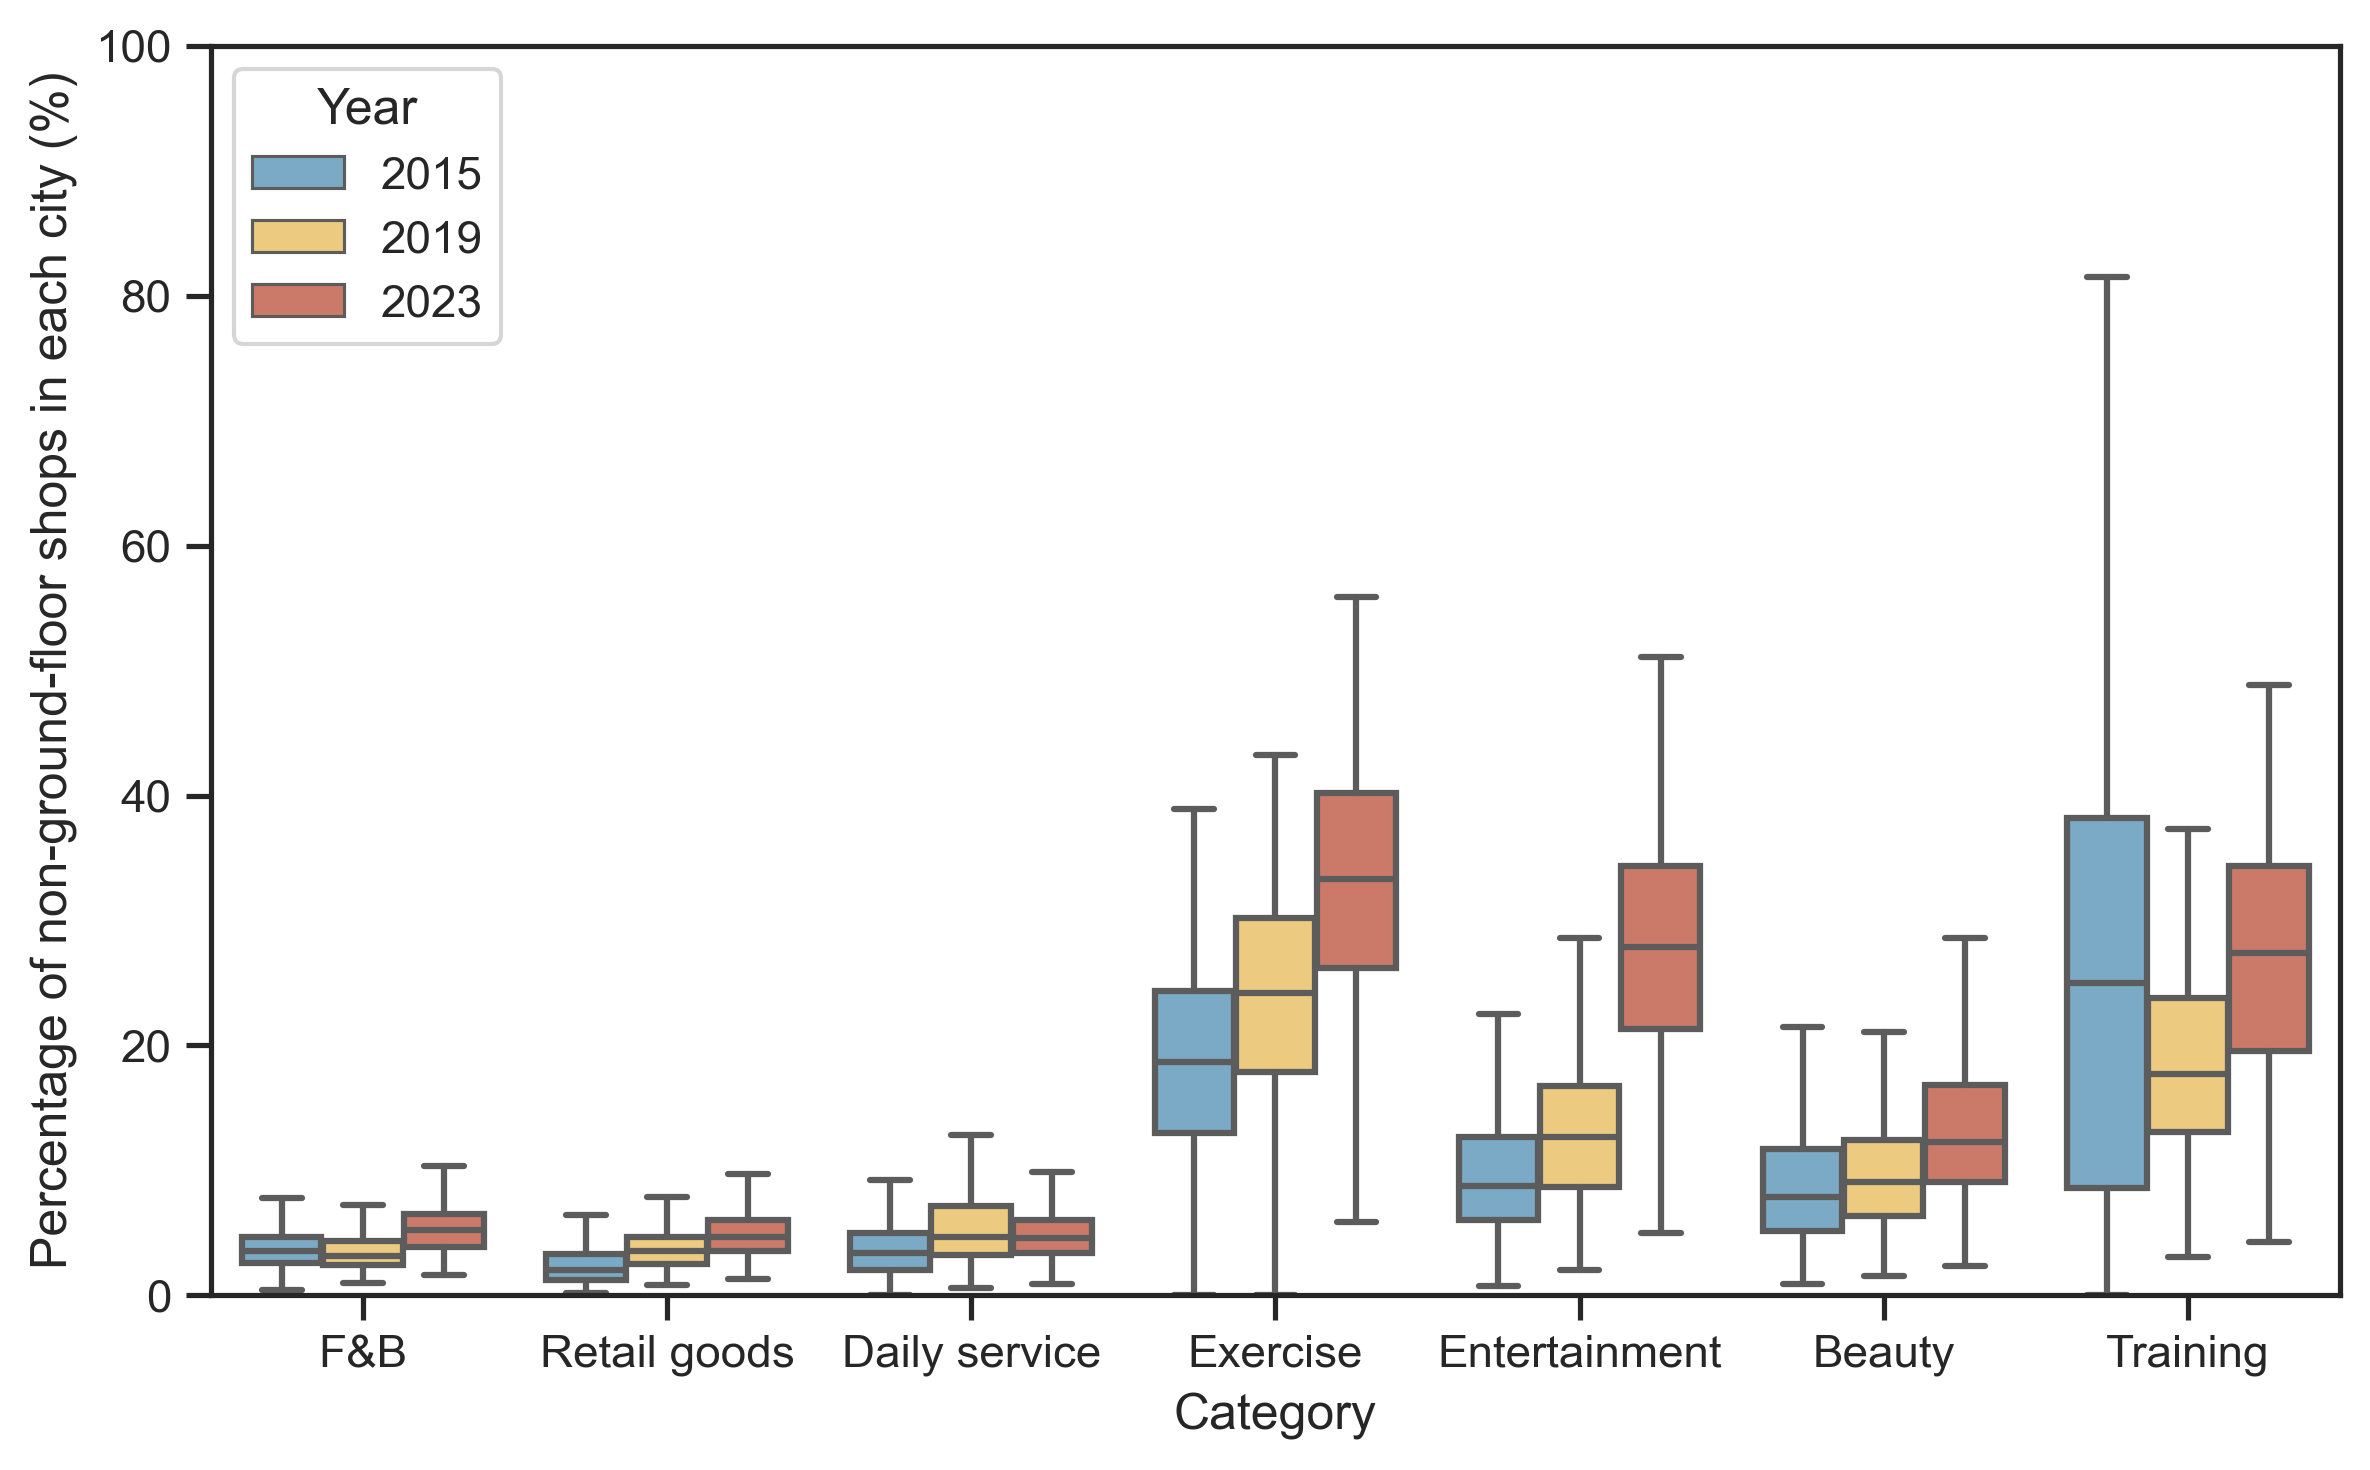

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



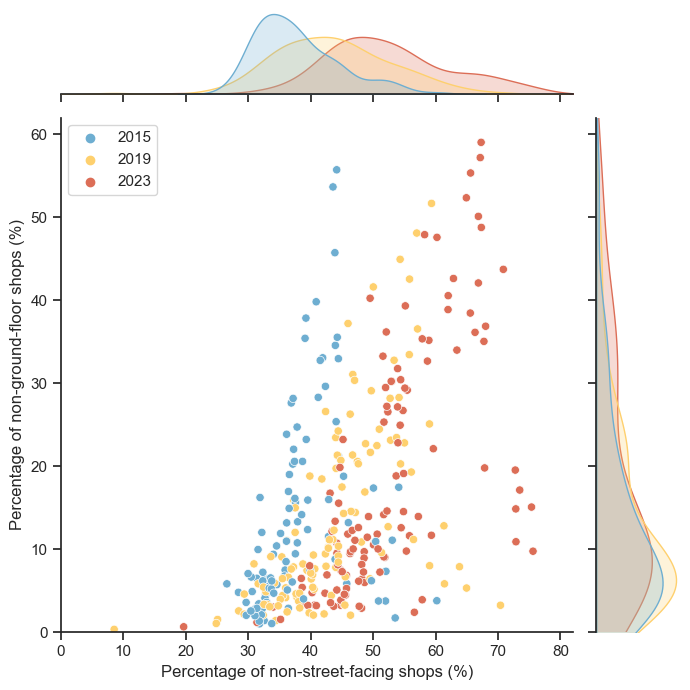

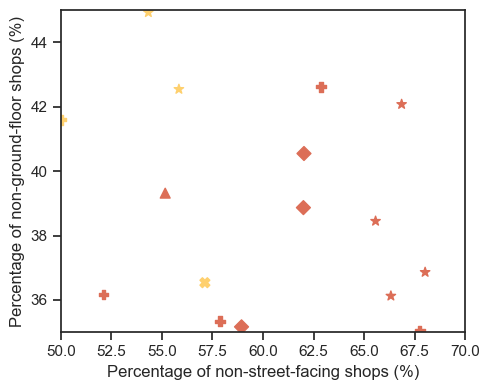

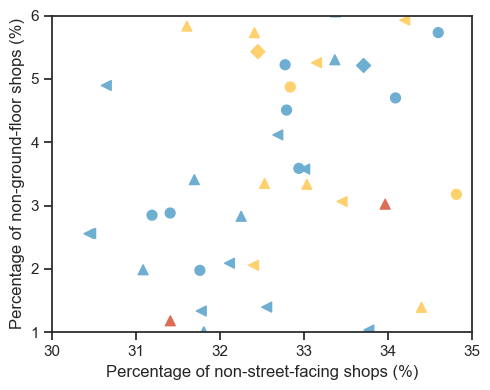

In [19]:
# Load data
def load_data():
    Typedata = pd.read_csv(data_path+'CityType.csv')
    groupedSC = pd.read_csv(data_path+'CitysubType.csv')
    return Typedata, groupedSC

# Save figure
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(f"{figure_path}/{filename}", format="svg", bbox_inches='tight')
    plt.show()

# Global settings
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12

# Color and marker definitions
colors = {2015: '#6eaed1', 2019: '#fed06e', 2023: '#dc6e57'}
markers = {
    'F&B': 'o', 
    'Retail goods': '<', 
    'Exercise': 'X', 
    'Entertainment': '*', 
    'Beauty': 'D', 
    'Training': 'P',
    'Daily service': '^'
}

# Fig.4a. NSF Boxplot 
def create_fig4a(data):
    order = ['F&B', 'Retail goods', 'Daily service', 'Exercise', 'Entertainment', 'Beauty', 'Training']
    plt.figure(figsize=(8, 5), dpi=300)
    
    sns.boxplot(
        data=data, 
        x='Big_cate', 
        y='P_NSF(%)', 
        hue='Year', 
        palette=colors, 
        showfliers=False, 
        order=order)

    plt.xlabel('Category')
    plt.ylabel('Percentage of non-street-facing shops in each city (%)')
    plt.ylim(0, 100)
    plt.legend(title='Year', loc='upper left')
    save_figure("Fig_4a_NSF_boxplot.svg")

# Fig.4b. NGF Boxplot
def create_fig4b(data):
    order = ['F&B', 'Retail goods', 'Daily service', 'Exercise', 'Entertainment', 'Beauty', 'Training'] 
    plt.figure(figsize=(8, 5), dpi=300)
        
    sns.boxplot(
        data=data, 
        x='Big_cate', 
        y='P_NGF(%)', 
        hue='Year', 
        palette=colors, 
        showfliers=False, 
        order=order
    )

    plt.xlabel('Category')
    plt.ylabel('Percentage of non-ground-floor shops in each city (%)')
    plt.ylim(0, 100)
    plt.legend(title='Year', loc='upper left')
    save_figure("Fig_4b_NGF_boxplot.svg")

# Fig.4c. Joint Scatter Plot 
def create_fig4c(data):
    g = sns.jointplot(
        y='P_NGF(%)', 
        x='P_NSF(%)', 
        data=data, 
        hue='Year', 
        palette=colors, 
        height=7
    )

    g.ax_joint.legend(loc='upper left')
    plt.ylim(0, 62)
    plt.xlim(0, 82)
    plt.xlabel('Percentage of non-street-facing shops (%)')
    plt.ylabel('Percentage of non-ground-floor shops (%)')
    save_figure("Fig_4c_joint_scatter.svg")

# Fig.4d. Scatter Plot (higher range)
def create_fig4d(data):
    plt.figure(figsize=(5, 4))
    for cat_en, group_data in data.groupby('Big_cate'):
        plt.scatter(
            x=group_data['P_NSF(%)'], 
            y=group_data['P_NGF(%)'], 
            label=cat_en, 
            marker=markers.get(cat_en, 'o'), 
            s=50,
            c=group_data['Year'].map(colors), 
        )
    
    plt.ylim(35, 45)
    plt.xlim(50, 70)
    plt.xlabel('Percentage of non-street-facing shops (%)')
    plt.ylabel('Percentage of non-ground-floor shops (%)')

    category_handles = [
        mlines.Line2D([], [], color='black', marker=marker, linestyle='None', 
                     markersize=8, label=cat_en)
        for cat_en, marker in markers.items()
    ]

    save_figure("Fig_4d_scatter_higher.svg")

# Fig.4e. Scatter Plot (lower range)
def create_fig4e(data):
    plt.figure(figsize=(5, 4))  
    for cat_en, group_data in data.groupby('Big_cate'):
        plt.scatter(
            x=group_data['P_NSF(%)'], 
            y=group_data['P_NGF(%)'], 
            label=cat_en, 
            marker=markers.get(cat_en, 'o'),
            s=50,
            c=group_data['Year'].map(colors),
        )
    
    plt.ylim(1, 6)
    plt.xlim(30, 35)
    plt.xlabel('Percentage of non-street-facing shops (%)')
    plt.ylabel('Percentage of non-ground-floor shops (%)')

    category_handles = [
        mlines.Line2D([], [], color='black', marker=marker, linestyle='None', 
                     markersize=8, label=cat_en)
        for cat_en, marker in markers.items()
    ]

    save_figure("Fig_4e_scatter_lower.svg")

if __name__ == "__main__":
    Typedata, groupedSC = load_data()
    create_fig4a(Typedata)    # NSF boxplot
    create_fig4b(Typedata)    # NGF boxplot
    create_fig4c(groupedSC)   # Joint scatter plot
    create_fig4d(groupedSC)   # Scatter plot (higher range)
    create_fig4e(groupedSC)   # Scatter plot (lower range)

## Fig. 5|Horizontal and vertical expansion across cities ##

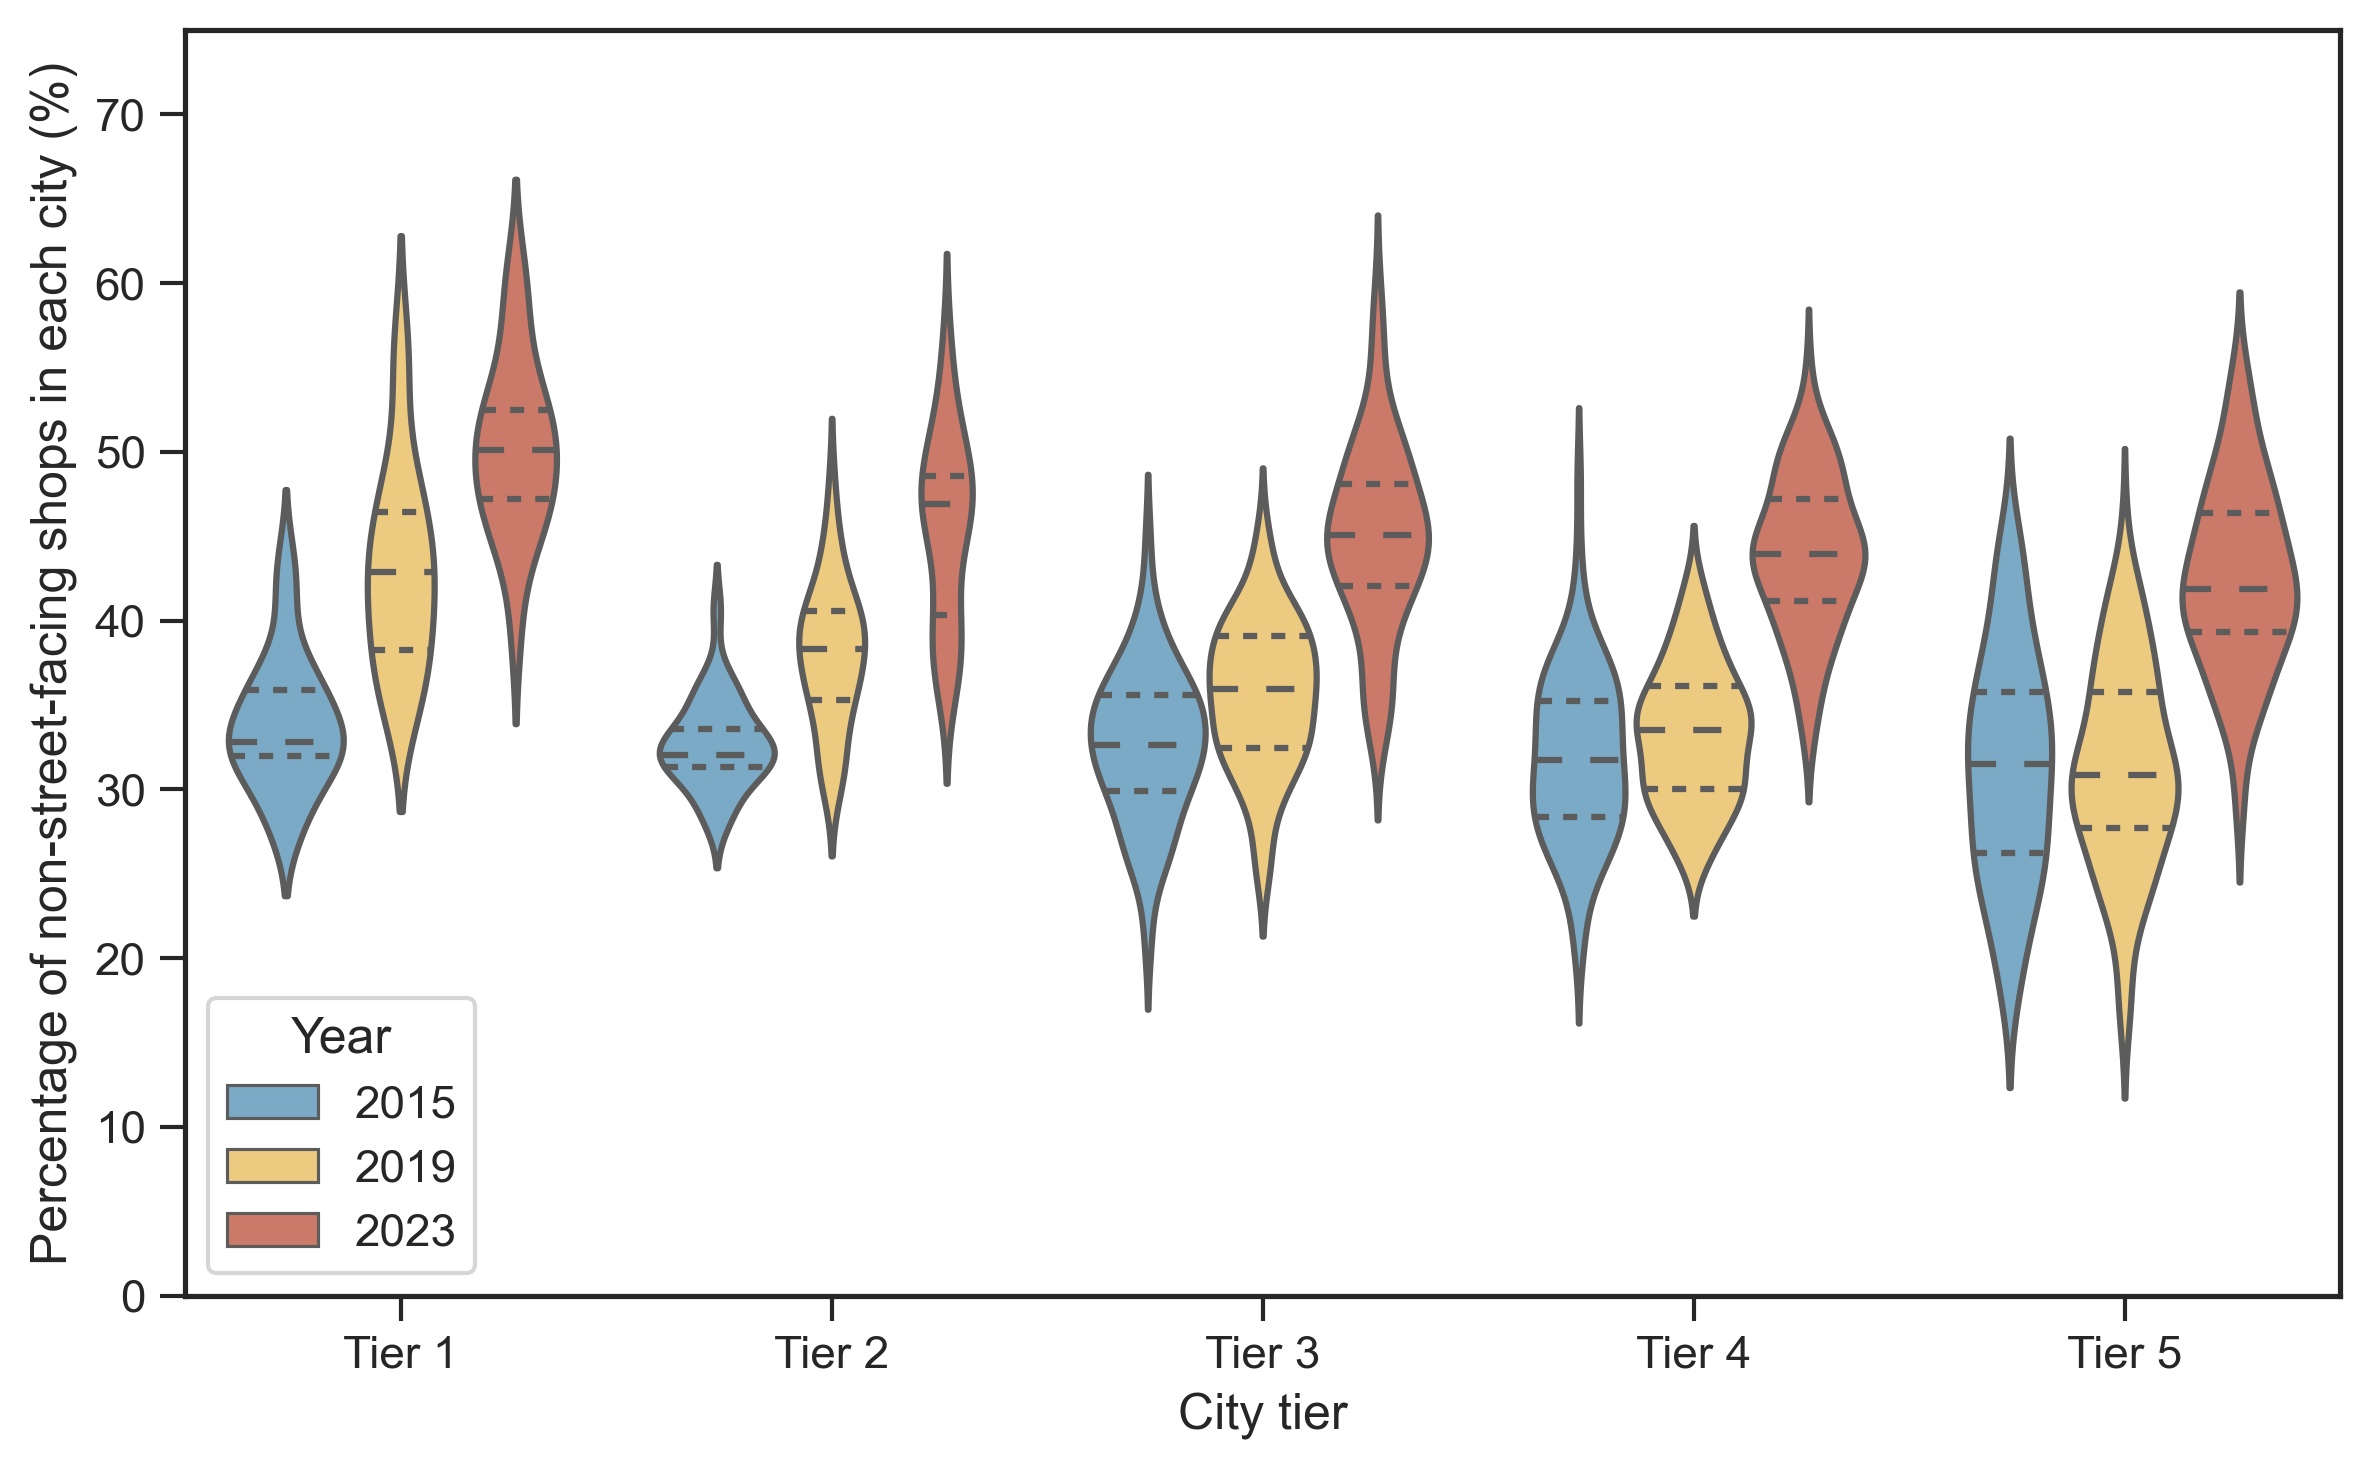

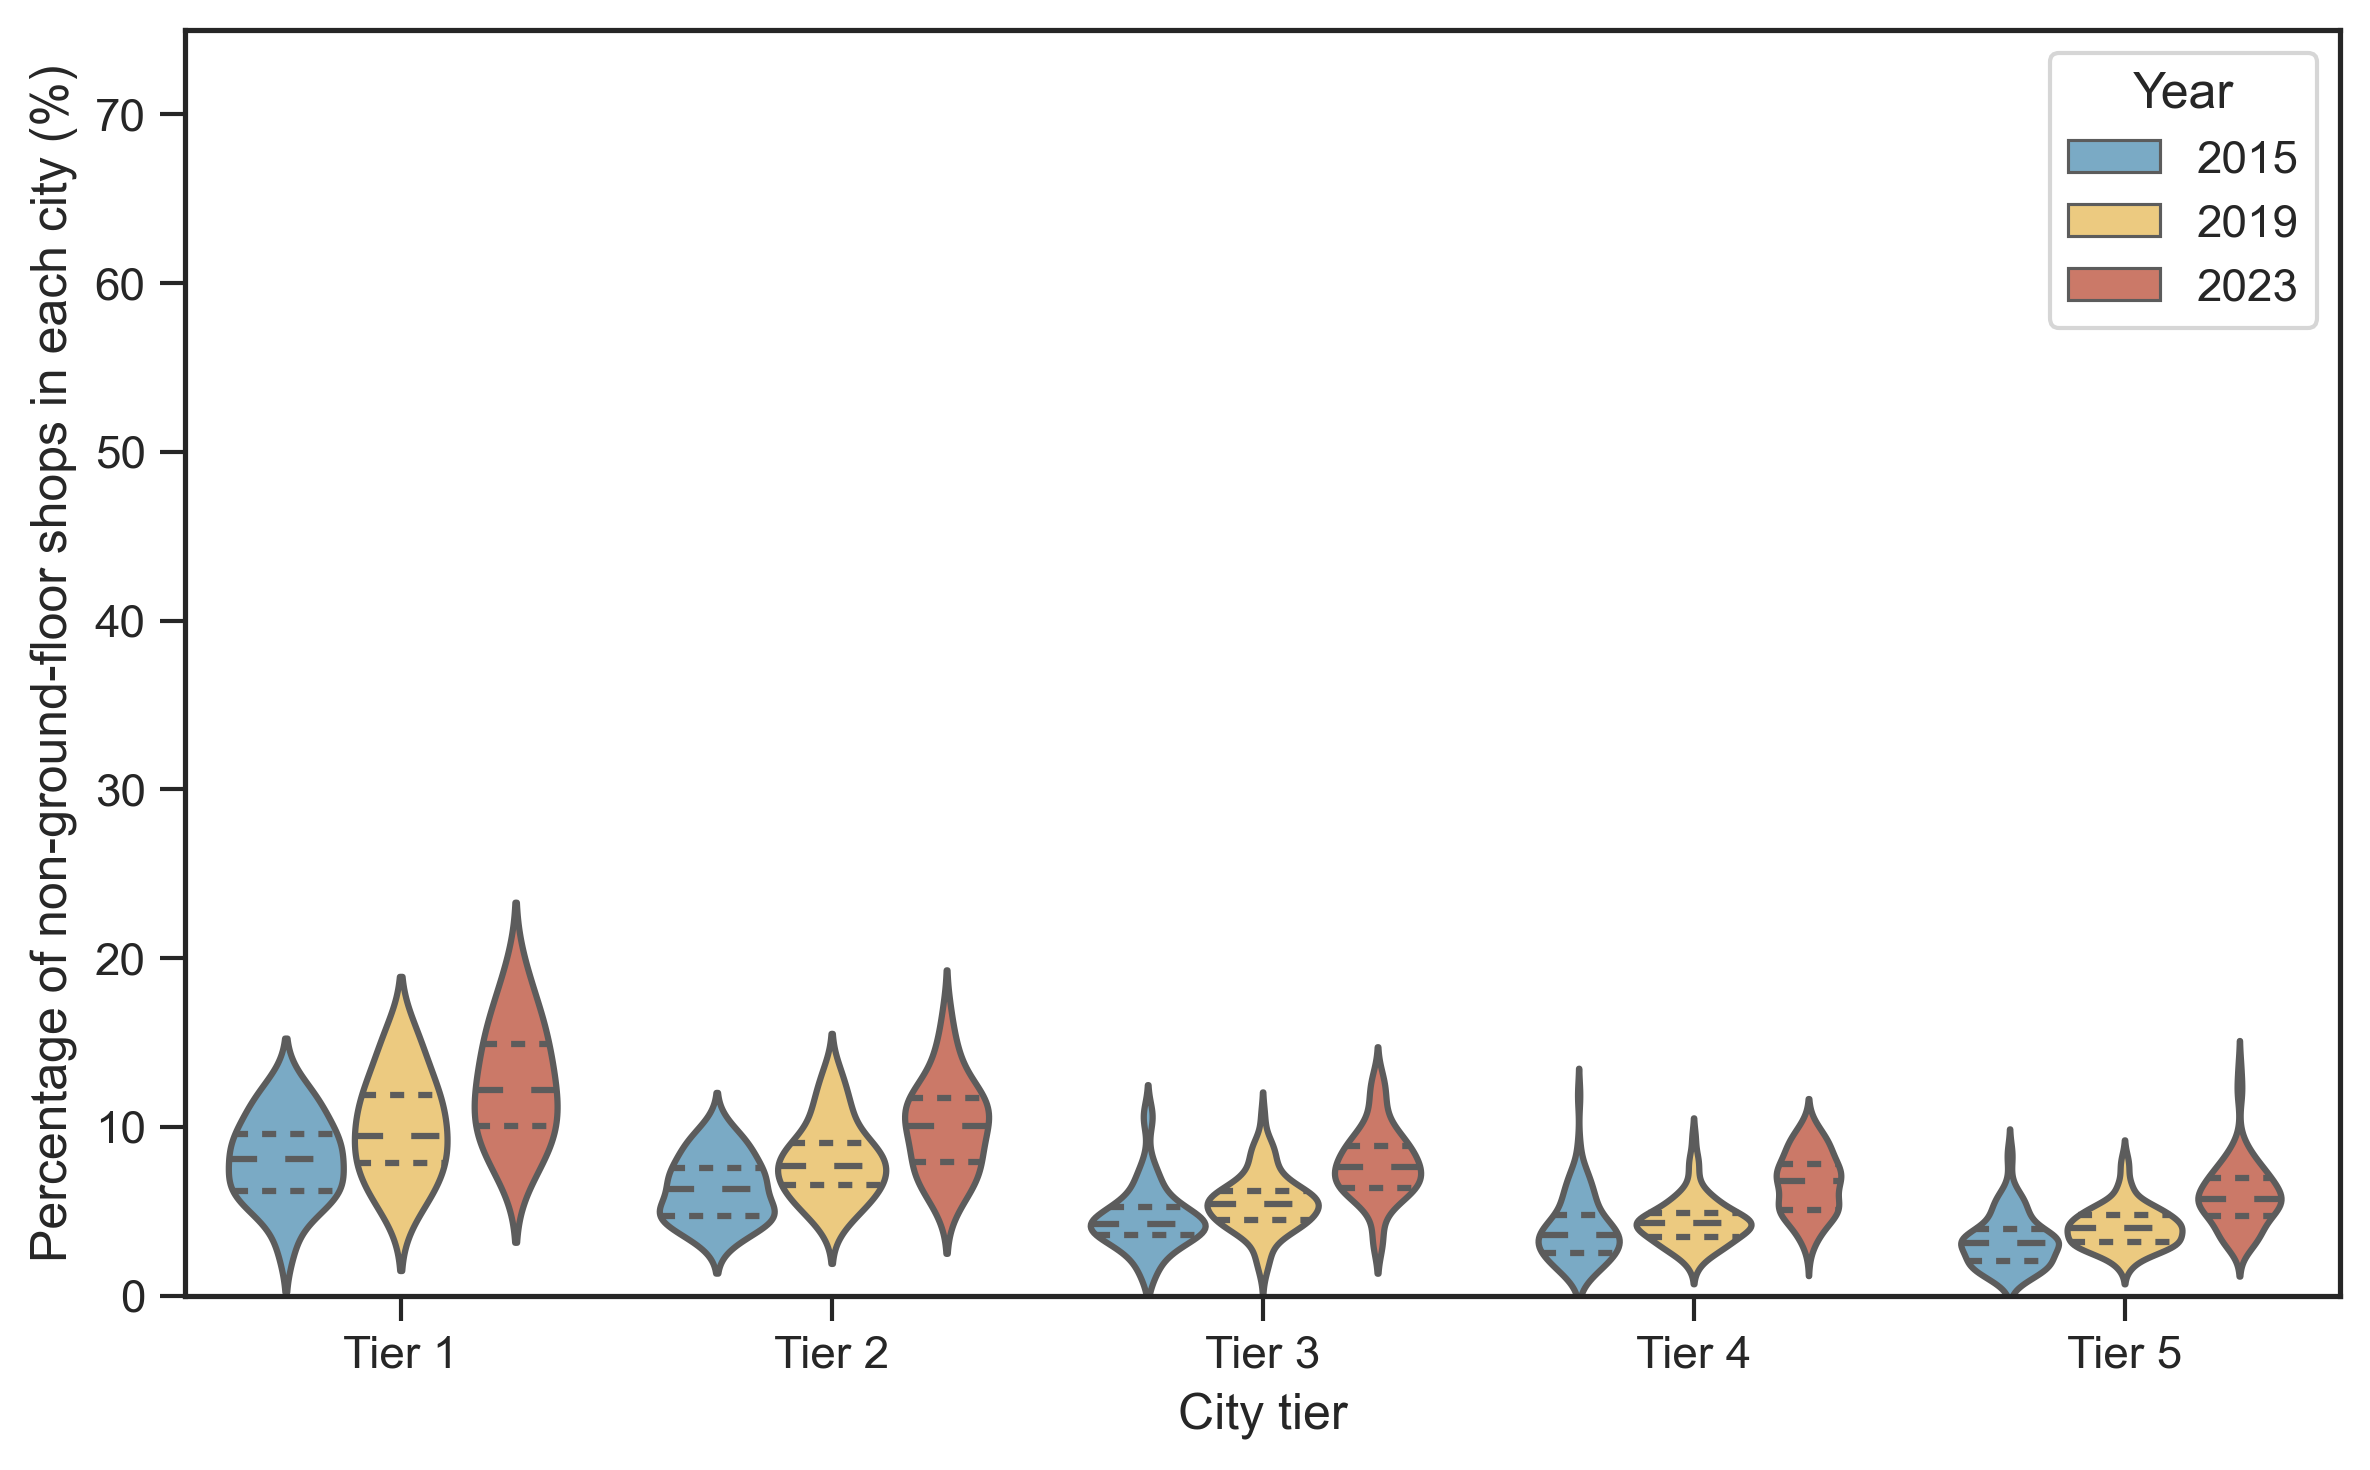

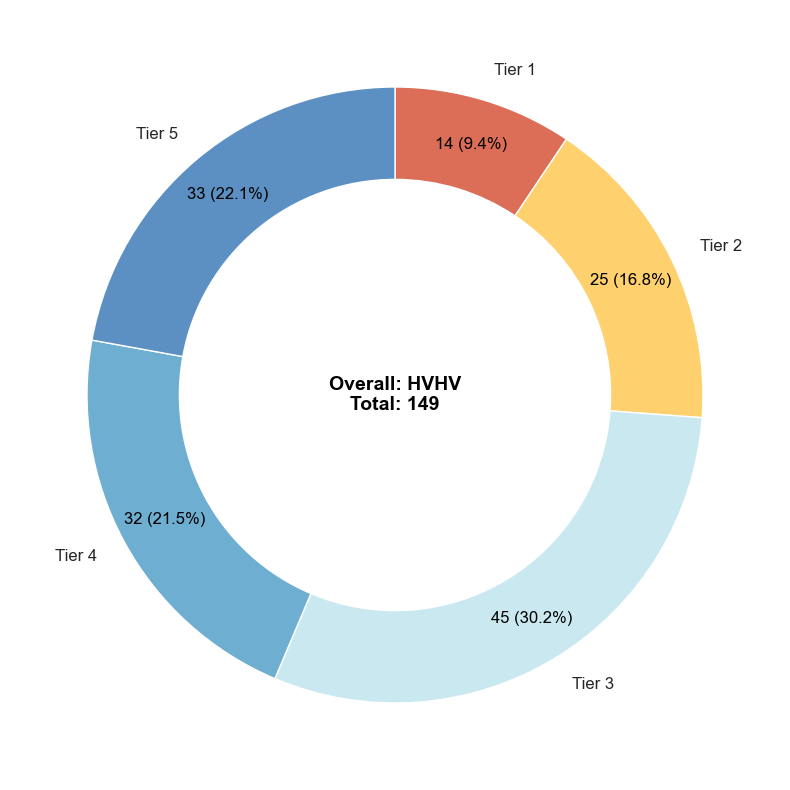

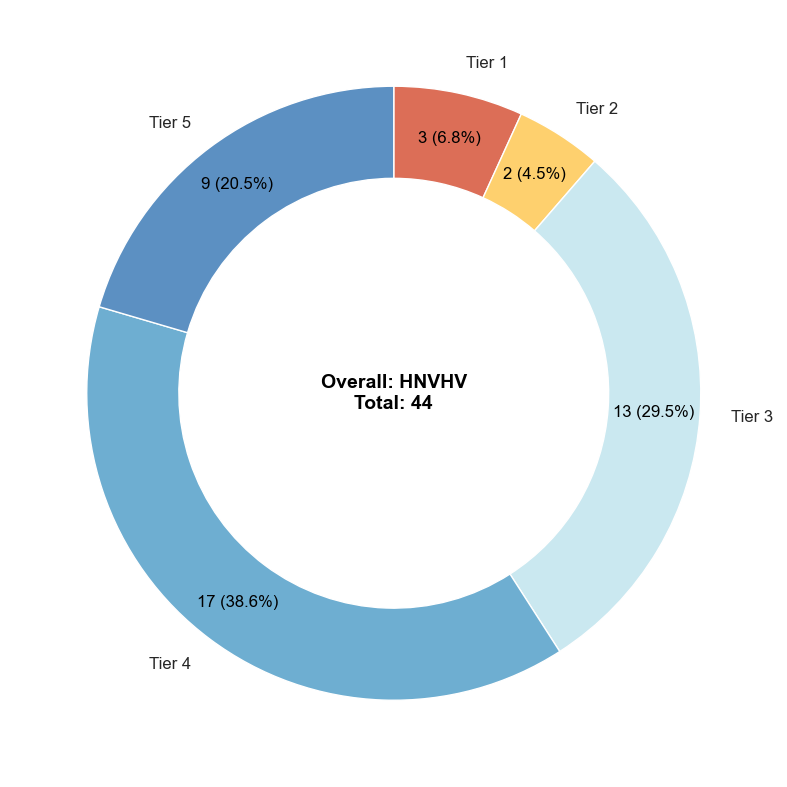

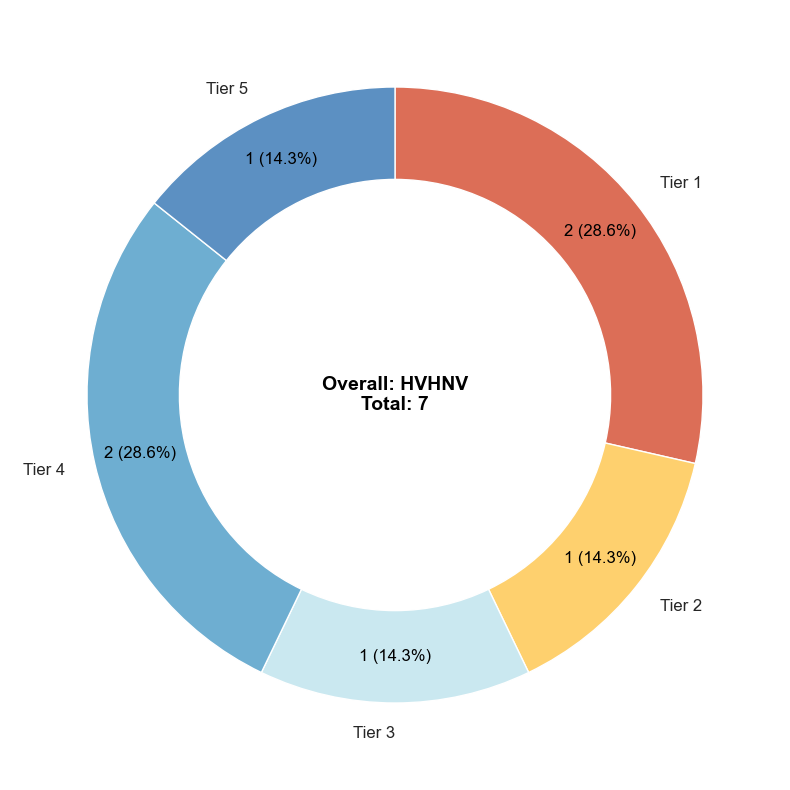

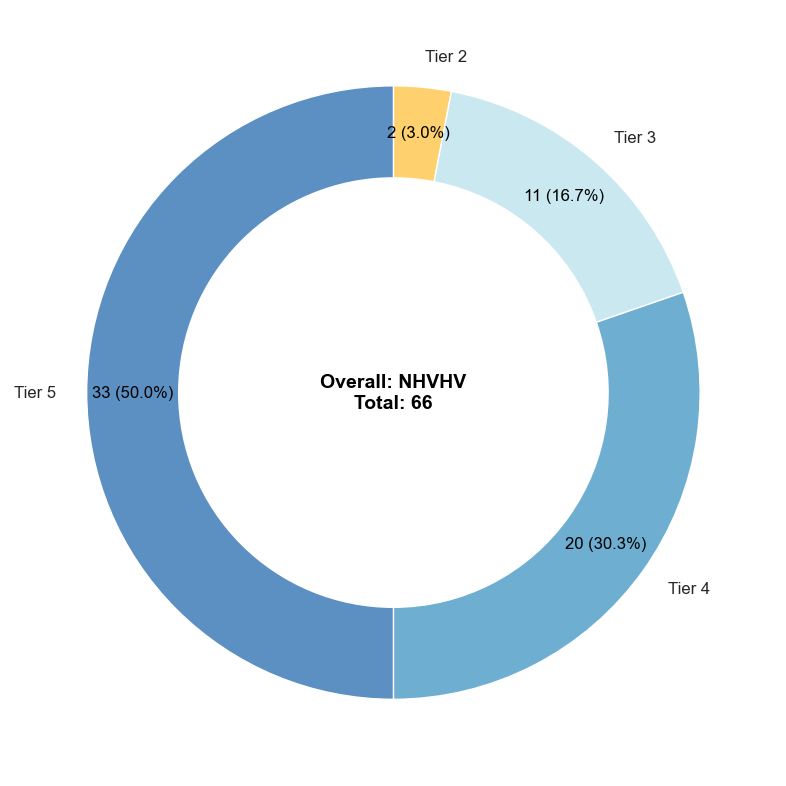

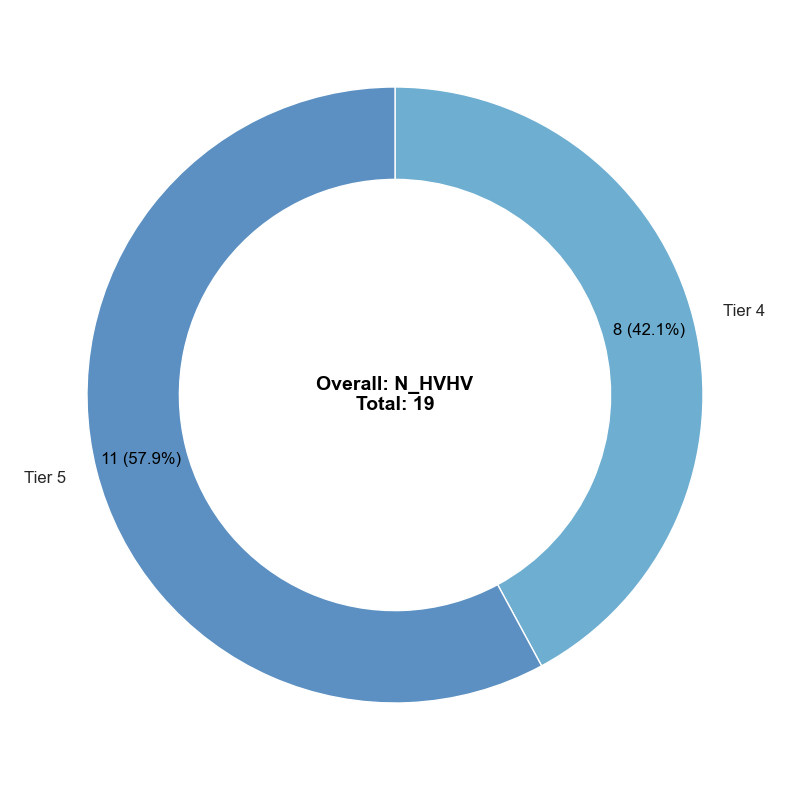

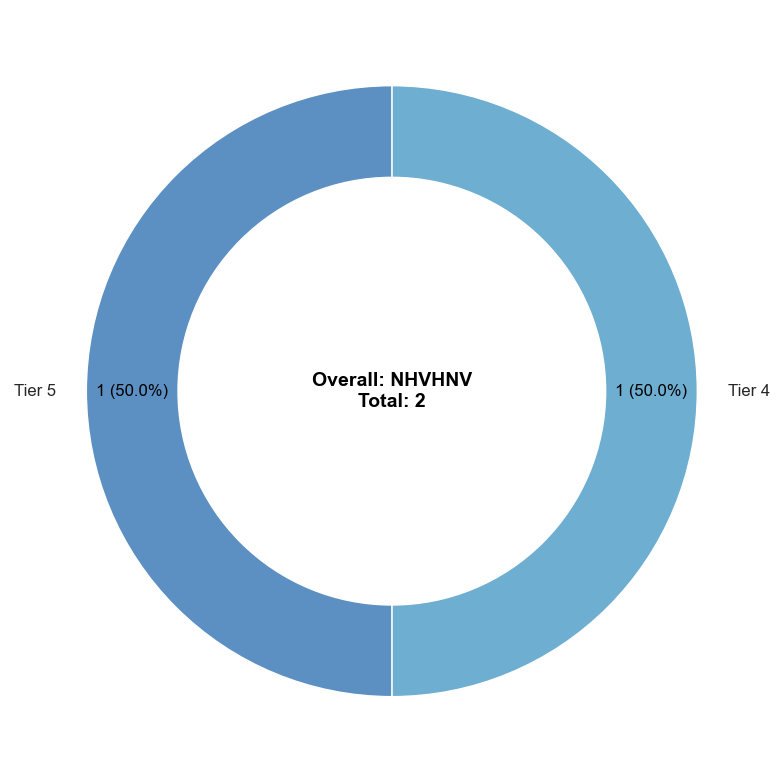

In [12]:
# Load data
data = pd.read_csv(data_path+'CityTier.csv')
grouped_data = pd.read_csv(data_path+'CityChange.csv')
datachange = pd.read_csv(data_path+'CityTierChange.csv')

# Save figure
def save_figure(filename):
    plt.tight_layout()
    plt.savefig(f"{figure_path}/{filename}", format="svg", bbox_inches='tight')
    plt.show()
    
# Global settings
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12

# Color definitions
colors = {
    2015: '#6eaed1',
    2019: '#fed06e',
    2023: '#dc6e57'
}
tier_colors = ['#dc6e57', '#fed06e', '#cae8f0', '#6eaed1', '#5c90c2']  
tier_order = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4', 'Tier 5']

# Fig.5a. NSF Violin Plot 
def create_fig5a(data):
    plt.figure(figsize=(8, 5), dpi=300)
    sns.violinplot(
        data=data,
        x='CityTier',
        y='P_NSF(%)',
        hue='Year',
        inner="quart",
        fill=True,
        palette=colors,
        order=tier_order 
    )

    plt.xlabel('City tier')
    plt.ylabel('Percentage of non-street-facing shops in each city (%)')
    plt.ylim(0, 75)
    plt.legend(title='Year', loc='lower left')
    plt.tick_params(axis='both', direction='out', length=6, width=1)
    save_figure("Fig_5a_NSF_violin.svg")

# Fig.5b. NGF Violin Plot
def create_fig5b(data):
    plt.figure(figsize=(8, 5), dpi=300)
    sns.violinplot(
        data=data,
        x='CityTier',
        y='P_NGF(%)',
        hue='Year',
        inner="quart",
        fill=True,
        palette=colors,
        order=tier_order 
    )

    plt.xlabel('City tier')
    plt.ylabel('Percentage of non-ground-floor shops in each city (%)')
    plt.ylim(0, 75)
    plt.legend(title='Year', loc='upper right')
    plt.tick_params(axis='both', direction='out', length=6, width=1)
    save_figure("Fig_5b_NGF_violin.svg")

# Fig.5c. Sankey Diagram
def create_fig5c(data):
    links = []
    for source_category in data['Category_2015_2019'].unique():
        for target_category in data['Category_2019_2023'].unique():
            value = data[
                (data['Category_2015_2019'] == source_category) & 
                (data['Category_2019_2023'] == target_category)
            ]['Count'].values
            
            if len(value) > 0 and value[0] > 0:
                links.append({
                    'source': f'2015-2019 {source_category}',
                    'target': f'2019-2023 {target_category}',
                    'value': value[0]
                })

    links_df = pd.DataFrame(links)
    all_nodes = list(links_df['source'].unique()) + list(links_df['target'].unique())
    node_indices = {node: idx for idx, node in enumerate(all_nodes)}
    links_df['source'] = links_df['source'].map(node_indices)
    links_df['target'] = links_df['target'].map(node_indices)

    node_colors = ['#528fac', '#6eaed1', '#fed06e', '#dc6e57'] * (len(all_nodes) // 4 + 1)
    node_colors = node_colors[:len(all_nodes)]
    node_colors_dict = {node: node_colors[idx] for idx, node in enumerate(all_nodes)}

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=15,
            thickness=10,
            line=dict(color='black', width=0.5),
            label=all_nodes,
            color=[node_colors_dict[node] for node in all_nodes]
        ),
        link=dict(
            source=links_df['source'],
            target=links_df['target'],
            value=links_df['value'],
            color=[node_colors_dict[all_nodes[idx]] for idx in links_df['source']],
            hovertemplate="Value: %{value}",
            hoverinfo="all"
        )
    ))

    fig.update_layout(
        title_text='Flow between Categories: 2015-2019 to 2019-2023',
        font_size=15,
        width=1000,
        height=800
    )
    fig.write_image(os.path.join(figure_path, "Fig_5c_sankey_diagram.svg"))

# Fig.5d. Tier Distribution Donut Charts
def create_fig5d(data):
    for overall_value in data['Overall'].unique():
        filtered_data = data[data['Overall'] == overall_value]
        tier_counts = filtered_data['CityTier'].value_counts()
        tier_counts = tier_counts.reindex(tier_order).fillna(0).astype(int)
        
        total_count = tier_counts.sum()
        tier_proportions = tier_counts / total_count * 100
        
        labels = [f'{tier}' if count > 0 else '' for tier, count in zip(tier_counts.index, tier_counts)]
        autotexts = [f'{count} ({prop:.1f}%)' if count > 0 else '' 
                    for count, prop in zip(tier_counts, tier_proportions)]

        fig, ax = plt.subplots(figsize=(8, 8))
        wedges, texts, autotexts_objs = ax.pie(
            tier_counts, 
            labels=labels, 
            autopct='%1.1f%%',
            startangle=90, 
            wedgeprops={'width': 0.3},
            colors=tier_colors,
            counterclock=False,
            pctdistance=0.85,
            textprops={'fontsize': 12}
        )

        for i, autotext in enumerate(autotexts_objs):
            autotext.set_text(autotexts[i])
            autotext.set_fontsize(12)
            autotext.set_color('black')

        ax.text(0, 0, f'Overall: {overall_value}\nTotal: {total_count}', 
                ha='center', va='center', 
                fontsize=14, fontweight='bold', color='black')

        save_figure(f"Fig_5{'d' if overall_value == 'Increase' else 'e'}_Fig_5d_{overall_value.lower()}.svg")

if __name__ == "__main__":    
    create_fig5a(data)          # Fig.5a. NSF Violin Plot 
    create_fig5b(data)          # Fig.5b. NGF Violin Plot
    create_fig5c(grouped_data)  # Fig.5c. Sankey Diagram
    create_fig5d(datachange)    # Fig.5d. Tier Distribution Donut Charts